<a href="https://colab.research.google.com/github/00Kique/CertMS/blob/main/Certificaci%C3%B3n_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Librerias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

Instalación de librerias

In [ ]:
!pip install --upgrade pip
!pip uninstall -y numpy pmdarima
!pip install numpy==1.24.4  # versión segura y compatible
!pip install pmdarima==2.0.3

ERROR: Operation cancelled by user
Found existing installation: numpy 1.24.4
Uninstalling numpy-1.24.4:
  Successfully uninstalled numpy-1.24.4
Found existing installation: pmdarima 2.0.3
Uninstalling pmdarima-2.0.3:
  Successfully uninstalled pmdarima-2.0.3
^C
ERROR: Operation cancelled by user
  Using cached pmdarima-2.0.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached pmdarima-2.0.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (1.9 MB)
Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pmdarima]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 require

Importacion del csv

In [ ]:
df = pd.read_csv('15 Years Stock Data of NVDA AAPL MSFT GOOGL and AMZN.csv')

Mostrar los primeros datos

In [ ]:
df.tail()

,Date,Close_AAPL,Close_AMZN,Close_GOOGL,Close_MSFT,Close_NVDA,High_AAPL,High_AMZN,High_GOOGL,High_MSFT,...,Open_GOOGL,Open_MSFT,Open_NVDA,Volume_AAPL,Volume_AMZN,Volume_GOOGL,Volume_MSFT,Volume_NVDA,Average_Close,Target
3769,2024-12-24,257.916443,229.050003,195.884399,438.450836,140.207108,257.926411,229.139999,195.884399,438.720315,...,194.615856,433.780209,139.987127,23234700,15007500,10403300,7164500,105157000,252.301758,1
3770,2024-12-26,258.735504,227.050003,195.375000,437.233276,139.917130,259.814335,228.500000,196.523671,440.057630,...,194.925505,438.201337,139.687155,27237100,16146700,12046600,8194200,116205600,251.662183,0
3771,2024-12-27,255.309296,223.750000,192.538254,429.668457,136.997391,258.415896,226.029999,195.095322,434.349074,...,194.725737,433.730320,138.537258,42355300,27367100,18891400,18117700,170582600,247.652679,0
3772,2024-12-30,251.923019,221.300003,191.020004,423.979858,137.477356,253.221595,223.000000,192.328495,426.694417,...,189.581658,425.207408,134.817597,35557500,28321200,14264700,13158700,167734700,245.140048,0
3773,2024-12-31,250.144974,219.389999,189.082245,420.656525,134.277649,253.001833,223.229996,191.739189,425.876070,...,190.860196,425.247326,138.017311,39480700,24819700,17466900,13246500,155659200,242.710278,0


Tipo de datos y cuantos datos tenemos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          3774 non-null   object 
 1   Close_AAPL    3774 non-null   float64
 2   Close_AMZN    3774 non-null   float64
 3   Close_GOOGL   3774 non-null   float64
 4   Close_MSFT    3774 non-null   float64
 5   Close_NVDA    3774 non-null   float64
 6   High_AAPL     3774 non-null   float64
 7   High_AMZN     3774 non-null   float64
 8   High_GOOGL    3774 non-null   float64
 9   High_MSFT     3774 non-null   float64
 10  High_NVDA     3774 non-null   float64
 11  Low_AAPL      3774 non-null   float64
 12  Low_AMZN      3774 non-null   float64
 13  Low_GOOGL     3774 non-null   float64
 14  Low_MSFT      3774 non-null   float64
 15  Low_NVDA      3774 non-null   float64
 16  Open_AAPL     3774 non-null   float64
 17  Open_AMZN     3774 non-null   float64
 18  Open_GOOGL    3774 non-null 

Observar si no existen valores nulos

In [ ]:
df.isnull().sum()

,0
Date,0
Close_AAPL,0
Close_AMZN,0
Close_GOOGL,0
Close_MSFT,0
Close_NVDA,0
High_AAPL,0
High_AMZN,0
High_GOOGL,0
High_MSFT,0


Descripción de los datos

In [ ]:
df.describe()

,Close_AAPL,Close_AMZN,Close_GOOGL,Close_MSFT,Close_NVDA,High_AAPL,High_AMZN,High_GOOGL,High_MSFT,High_NVDA,...,Open_AAPL,Open_AMZN,Open_GOOGL,Open_MSFT,Open_NVDA,Volume_AAPL,Volume_AMZN,Volume_GOOGL,Volume_MSFT,Volume_NVDA
count,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,...,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03,3.774000e+03,3.774000e+03,3.774000e+03,3.774000e+03
mean,67.521690,71.444840,61.149777,129.578311,13.977600,68.176227,72.272163,61.762884,130.770886,14.231440,...,67.465510,71.459697,61.128255,129.547155,13.979288,2.299200e+08,8.321625e+07,5.617230e+07,3.616344e+07,4.969955e+08
std,65.602673,61.124111,46.638356,124.987871,28.088261,66.212381,61.843003,47.144306,126.104839,28.610675,...,65.523836,61.149296,46.612714,124.977587,28.117355,2.180726e+08,5.168606e+07,4.749974e+07,2.085042e+07,3.064756e+08
min,5.779478,5.430500,10.860739,17.447613,0.203574,5.898345,5.564500,11.015403,17.682676,0.207472,...,5.789105,5.296500,10.916527,17.508276,0.199906,2.323470e+07,1.500750e+07,9.312000e+06,7.164500e+06,4.564400e+07
25%,17.461680,14.987375,22.581480,28.772202,0.411332,17.645443,15.183750,22.738201,28.981824,0.418210,...,17.465271,15.000000,22.600904,28.766031,0.412650,8.492275e+07,5.234320e+07,2.733450e+07,2.262030e+07,3.034280e+08
50%,35.323715,48.394751,47.151819,64.985474,3.544295,35.728738,48.818001,47.410334,65.429323,3.594330,...,35.354713,48.577499,47.140873,64.852778,3.515616,1.403920e+08,7.007700e+07,3.768900e+07,3.022110e+07,4.283440e+08
75%,126.909601,120.965000,93.473120,228.535389,13.567127,127.999184,122.692247,94.761573,231.254503,13.823134,...,126.339104,120.822123,93.317730,228.850363,13.597044,3.081386e+08,9.872150e+07,7.315977e+07,4.420790e+07,6.025145e+08
max,258.735504,232.929993,196.433777,464.854340,148.856064,259.814335,233.000000,201.188288,465.639777,152.865409,...,257.906429,232.389999,197.023087,464.297590,149.325985,1.880998e+09,8.484220e+08,5.923990e+08,3.193179e+08,3.692928e+09


Observar los histogramas si existen outlier

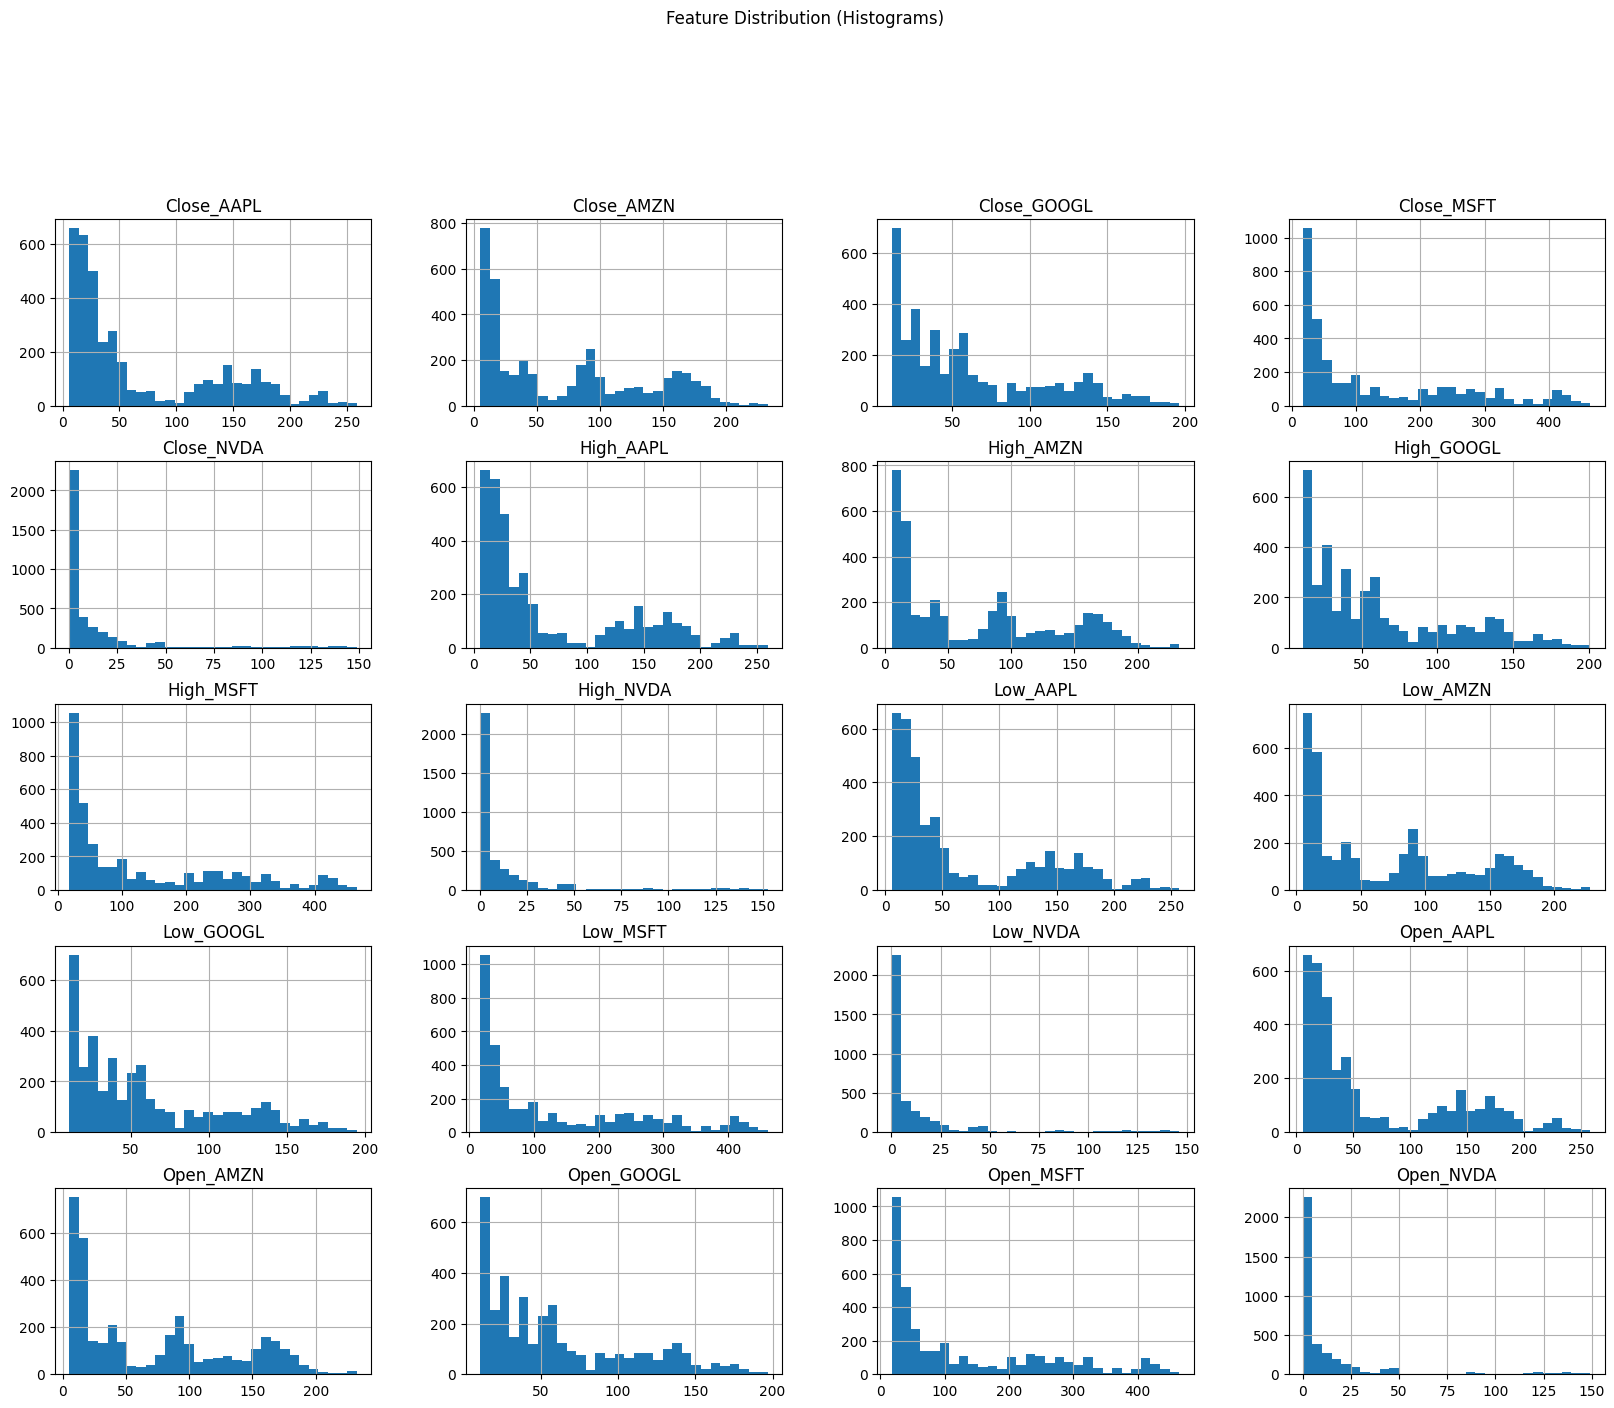

In [ ]:
# Histograms for all numeric features
df[['Close_AAPL', 'Close_AMZN', 'Close_GOOGL', 'Close_MSFT', 'Close_NVDA', 'High_AAPL', 'High_AMZN', 'High_GOOGL', 'High_MSFT',
    'High_NVDA', 'Low_AAPL', 'Low_AMZN', 'Low_GOOGL', 'Low_MSFT', 'Low_NVDA', 'Open_AAPL', 'Open_AMZN', 'Open_GOOGL', 'Open_MSFT',
    'Open_NVDA']].hist(bins=30, figsize=(20, 15))
plt.suptitle('Feature Distribution (Histograms)', y=1.02)
plt.show()

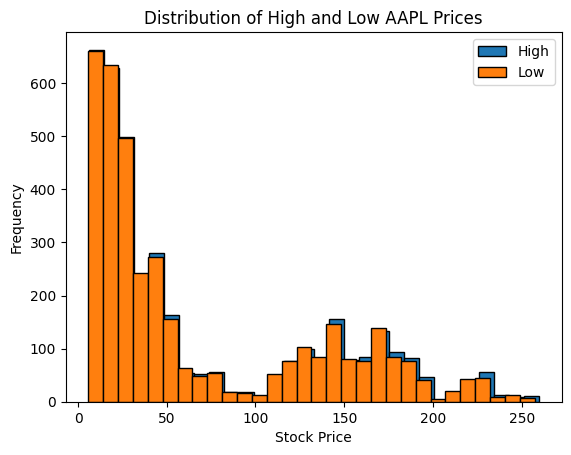

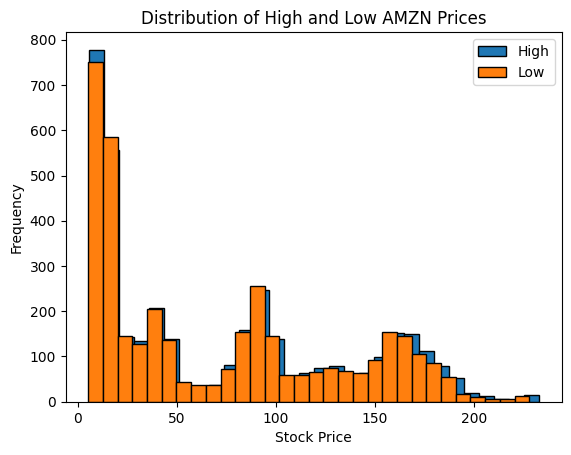

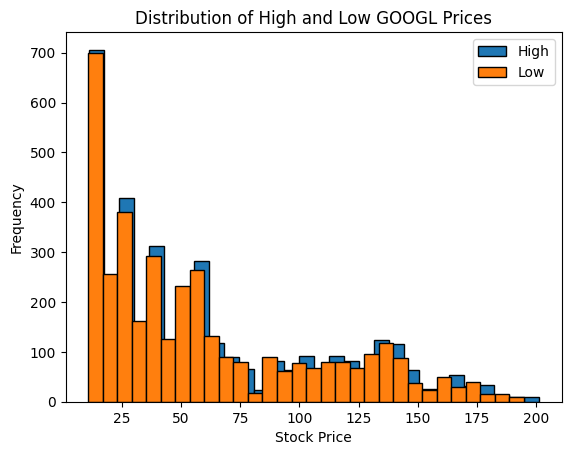

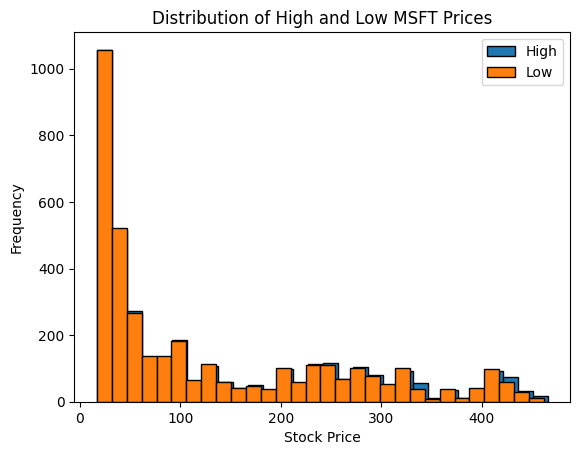

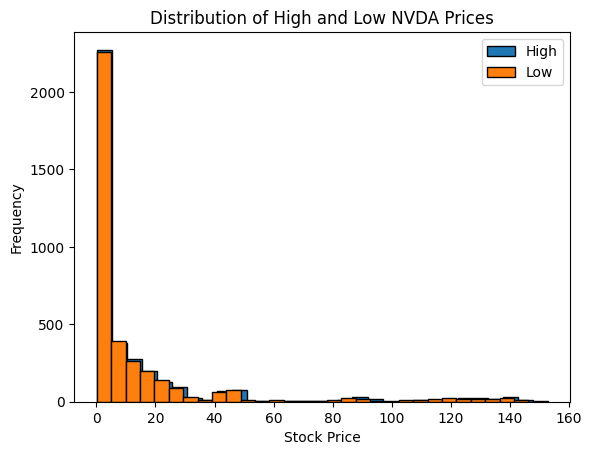

In [ ]:
stocks = ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA']

for stock in stocks:
    plt.hist(df[f'High_{stock}'], bins=30, edgecolor='black')
    plt.hist(df[f'Low_{stock}'], bins=30, edgecolor='black')

    plt.title(f'Distribution of High and Low {stock} Prices')
    plt.xlabel('Stock Price')
    plt.ylabel('Frequency')
    plt.legend(['High', 'Low'])
    plt.show()

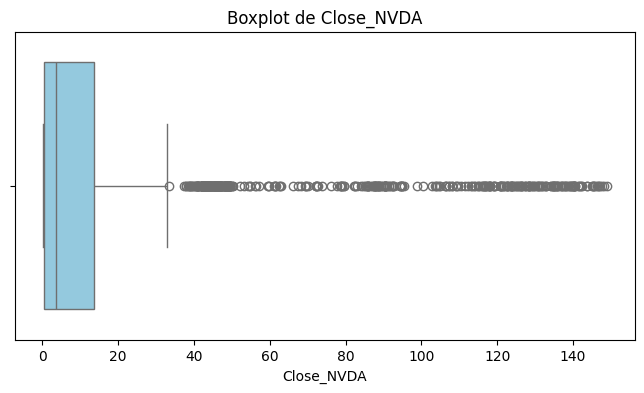

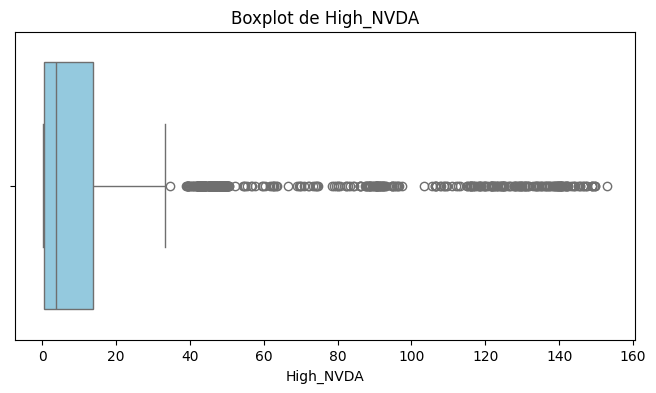

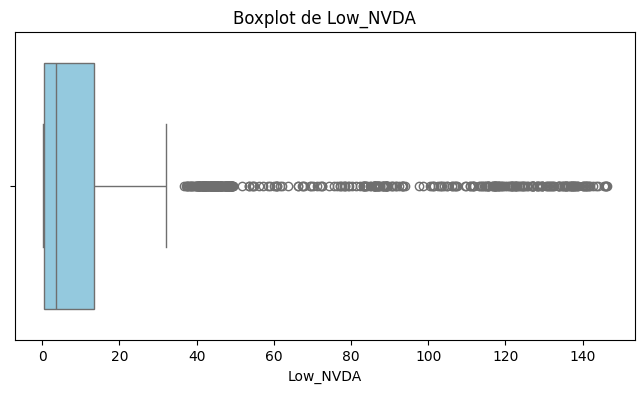

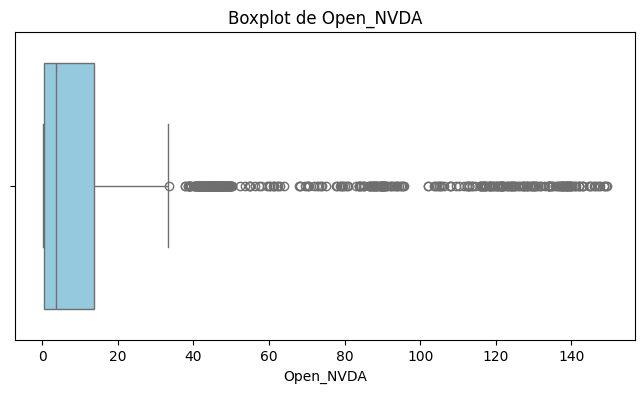

In [ ]:
variables = ['Close_NVDA', 'High_NVDA', 'Low_NVDA', 'Open_NVDA']

for var in variables:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=var, color='skyblue')
    plt.xlabel(var)
    plt.title(f'Boxplot de {var}')
    plt.show()

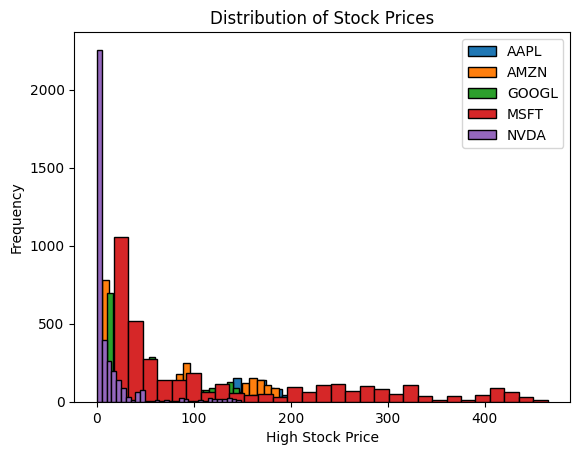

In [ ]:
plt.hist(df['Close_AAPL'], bins=30, edgecolor='black')
plt.hist(df['Close_AMZN'], bins=30, edgecolor='black')
plt.hist(df['Close_GOOGL'], bins=30, edgecolor='black')
plt.hist(df['Close_MSFT'], bins=30, edgecolor='black')
plt.hist(df['Close_NVDA'], bins=30, edgecolor='black')

plt.title('Distribution of Stock Prices')
plt.xlabel('High Stock Price')
plt.ylabel('Frequency')
plt.legend(['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA'])
plt.show()

In [ ]:
#df.drop([], axis=1, inplace=True)

In [ ]:
# Convertir la columna Date a tipo datetime y ordenar
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

# Crear índice de mercado como promedio del cierre de las 5 acciones
close_columns = ['Close_AAPL', 'Close_AMZN', 'Close_GOOGL', 'Close_MSFT', 'Close_NVDA']
df['Market_Close_Index'] = df[close_columns].mean(axis=1)

# Crear la columna target: 1 si sube al siguiente día, 0 si baja o se mantiene
df['Market_Close_Next_Day'] = df['Market_Close_Index'].shift(-1)
df['Target'] = (df['Market_Close_Next_Day'] > df['Market_Close_Index']).astype(int)

# Crear características con retrasos (lags) de 1 a 5 días para las columnas Open y Close
for col in close_columns:
    for lag in range(1, 6):
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

open_columns = ['Open_AAPL', 'Open_AMZN', 'Open_GOOGL', 'Open_MSFT', 'Open_NVDA']
for col in open_columns:
    for lag in range(1, 6):
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# Eliminar filas con NaN introducidas por los shifts
df_model = df.dropna().reset_index(drop=True)

# Mostrar las primeras filas del dataset listo para entrenamiento
df_model[['Date', 'Market_Close_Index', 'Market_Close_Next_Day', 'Target'] +
         [col for col in df_model.columns if 'lag' in col]].head()


,Date,Market_Close_Index,Market_Close_Next_Day,Target,Close_AAPL_lag1,Close_AAPL_lag2,Close_AAPL_lag3,Close_AAPL_lag4,Close_AAPL_lag5,Close_AMZN_lag1,...,Open_MSFT_lag1,Open_MSFT_lag2,Open_MSFT_lag3,Open_MSFT_lag4,Open_MSFT_lag5,Open_NVDA_lag1,Open_NVDA_lag2,Open_NVDA_lag3,Open_NVDA_lag4,Open_NVDA_lag5
0,2010-01-11,10.194424,10.064592,0,6.379242,6.337109,6.348847,6.451465,6.440330,6.6760,...,22.750656,23.013616,23.201455,23.178910,23.006108,0.420903,0.430532,0.429844,0.422279,0.424342
1,2010-01-12,10.064592,10.126116,1,6.322966,6.379242,6.337109,6.348847,6.451465,6.5155,...,23.073731,22.750656,23.013616,23.201455,23.178910,0.427552,0.420903,0.430532,0.429844,0.422279
2,2010-01-13,10.126116,10.205301,1,6.251042,6.322966,6.379242,6.337109,6.348847,6.3675,...,22.652972,23.073731,22.750656,23.013616,23.201455,0.413109,0.427552,0.420903,0.430532,0.429844
3,2010-01-14,10.205301,10.115661,0,6.339215,6.251042,6.322966,6.379242,6.337109,6.4555,...,22.735623,22.652972,23.073731,22.750656,23.013616,0.407836,0.413109,0.427552,0.420903,0.430532
4,2010-01-15,10.115661,10.250680,1,6.302503,6.339215,6.251042,6.322966,6.379242,6.3675,...,22.773184,22.735623,22.652972,23.073731,22.750656,0.405544,0.407836,0.413109,0.427552,0.420903


In [ ]:
df.head()

,Date,Close_AAPL,Close_AMZN,Close_GOOGL,Close_MSFT,Close_NVDA,High_AAPL,High_AMZN,High_GOOGL,High_MSFT,...,Open_MSFT_lag1,Open_MSFT_lag2,Open_MSFT_lag3,Open_MSFT_lag4,Open_MSFT_lag5,Open_NVDA_lag1,Open_NVDA_lag2,Open_NVDA_lag3,Open_NVDA_lag4,Open_NVDA_lag5
0,2010-01-04,6.440330,6.6950,15.609805,23.254051,0.423884,6.455075,6.8305,15.678546,23.366752,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,6.451465,6.7345,15.541064,23.261557,0.430073,6.487878,6.7740,15.636953,23.366746,...,23.006108,NaN,NaN,NaN,NaN,0.424342,NaN,NaN,NaN,NaN
2,2010-01-06,6.348847,6.6125,15.149294,23.118809,0.432824,6.477046,6.7365,15.587638,23.351725,...,23.178910,23.006108,NaN,NaN,NaN,0.422279,0.424342,NaN,NaN,NaN
3,2010-01-07,6.337109,6.5000,14.796624,22.878376,0.424342,6.379842,6.6160,15.192630,23.066212,...,23.201455,23.178910,23.006108,NaN,NaN,0.429844,0.422279,0.424342,NaN,NaN
4,2010-01-08,6.379242,6.6760,14.993881,23.036165,0.425259,6.379844,6.6840,15.024515,23.201460,...,23.013616,23.201455,23.178910,23.006108,NaN,0.430532,0.429844,0.422279,0.424342,NaN


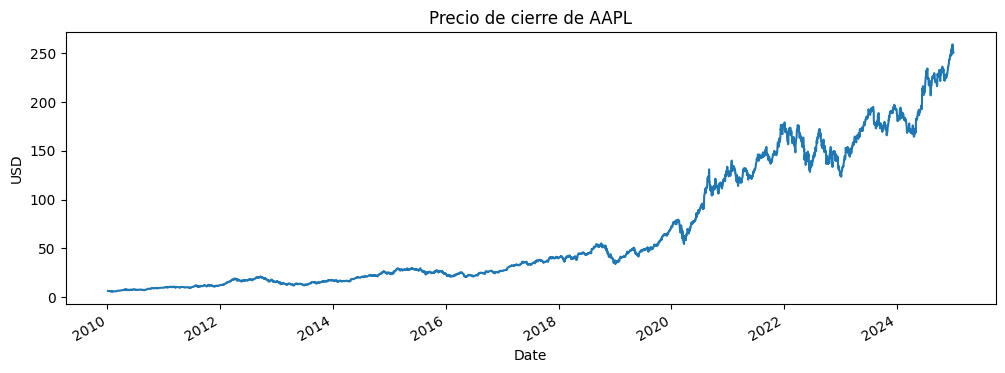

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

Predicción de cierre (10 días):
3774    250.146051
3775    250.300124
3776    250.495531
3777    250.265062
3778    250.221063
3779    250.212856
3780    250.103341
3781    250.094355
3782    250.097750
3783    250.147259
Name: predicted_mean, dtype: float64

¿Sube respecto al último cierre?
Día 1: Sube (predicho: 250.15, actual: 250.14)
Día 2: Sube (predicho: 250.30, actual: 250.14)
Día 3: Sube (predicho: 250.50, actual: 250.14)
Día 4: Sube (predicho: 250.27, actual: 250.14)
Día 5: Sube (predicho: 250.22, actual: 250.14)
Día 6: Sube (predicho: 250.21, actual: 250.14)
Día 7: Baja (predicho: 250.10, actual: 250.14)
Día 8: Baja (predicho: 250.09, actual: 250.14)
Día 9: Baja (predicho: 250.10, actual: 250.14)
Día 10: Sube (predicho: 250.15, actual: 250.14)


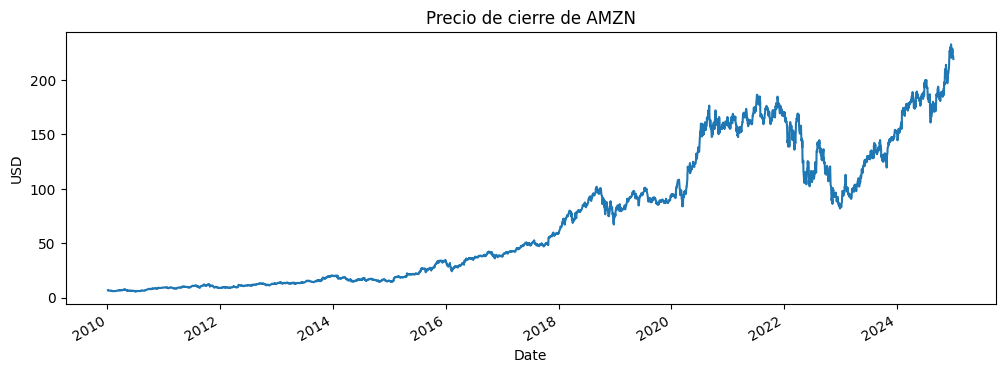

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

Predicción de cierre (10 días):
3774    219.333846
3775    219.622530
3776    219.437156
3777    219.145225
3778    219.266198
3779    219.306065
3780    219.494294
3781    219.684956
3782    219.772305
3783    219.819311
Name: predicted_mean, dtype: float64

¿Sube respecto al último cierre?
Día 1: Baja (predicho: 219.33, actual: 219.39)
Día 2: Sube (predicho: 219.62, actual: 219.39)
Día 3: Sube (predicho: 219.44, actual: 219.39)
Día 4: Baja (predicho: 219.15, actual: 219.39)
Día 5: Baja (predicho: 219.27, actual: 219.39)
Día 6: Baja (predicho: 219.31, actual: 219.39)
Día 7: Sube (predicho: 219.49, actual: 219.39)
Día 8: Sube (predicho: 219.68, actual: 219.39)
Día 9: Sube (predicho: 219.77, actual: 219.39)
Día 10: Sube (predicho: 219.82, actual: 219.39)


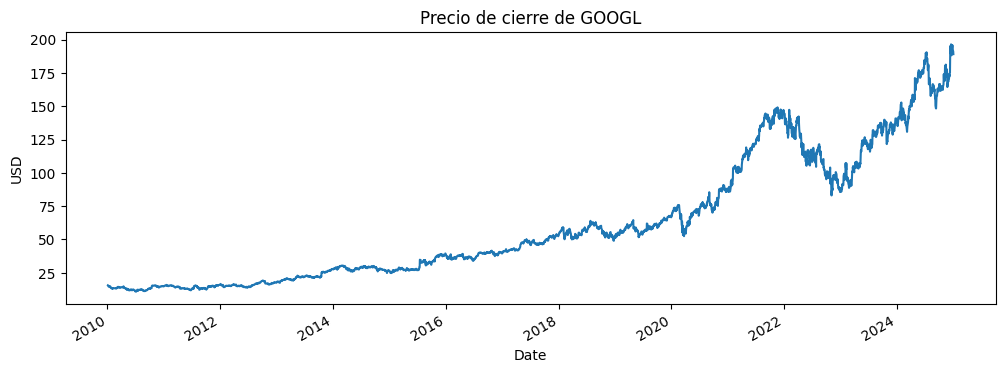

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

Predicción de cierre (10 días):
3774    188.904304
3775    189.203991
3776    189.546587
3777    189.754715
3778    189.760396
3779    189.734728
3780    189.528741
3781    189.492759
3782    189.416633
3783    189.446831
Name: predicted_mean, dtype: float64

¿Sube respecto al último cierre?
Día 1: Baja (predicho: 188.90, actual: 189.08)
Día 2: Sube (predicho: 189.20, actual: 189.08)
Día 3: Sube (predicho: 189.55, actual: 189.08)
Día 4: Sube (predicho: 189.75, actual: 189.08)
Día 5: Sube (predicho: 189.76, actual: 189.08)
Día 6: Sube (predicho: 189.73, actual: 189.08)
Día 7: Sube (predicho: 189.53, actual: 189.08)
Día 8: Sube (predicho: 189.49, actual: 189.08)
Día 9: Sube (predicho: 189.42, actual: 189.08)
Día 10: Sube (predicho: 189.45, actual: 189.08)


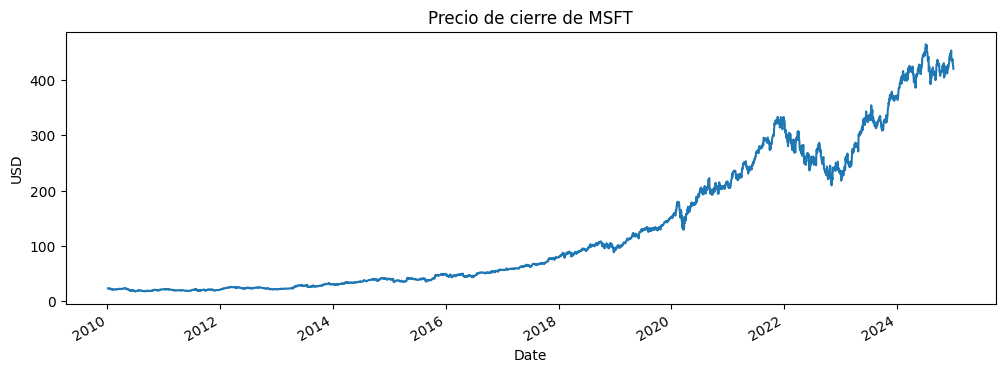

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

Predicción de cierre (10 días):
3774    420.043082
3775    420.359050
3776    420.268537
3777    420.111426
3778    420.484726
3779    420.598276
3780    420.249169
3781    420.134351
3782    420.076701
3783    420.120209
Name: predicted_mean, dtype: float64

¿Sube respecto al último cierre?
Día 1: Baja (predicho: 420.04, actual: 420.66)
Día 2: Baja (predicho: 420.36, actual: 420.66)
Día 3: Baja (predicho: 420.27, actual: 420.66)
Día 4: Baja (predicho: 420.11, actual: 420.66)
Día 5: Baja (predicho: 420.48, actual: 420.66)
Día 6: Baja (predicho: 420.60, actual: 420.66)
Día 7: Baja (predicho: 420.25, actual: 420.66)
Día 8: Baja (predicho: 420.13, actual: 420.66)
Día 9: Baja (predicho: 420.08, actual: 420.66)
Día 10: Baja (predicho: 420.12, actual: 420.66)


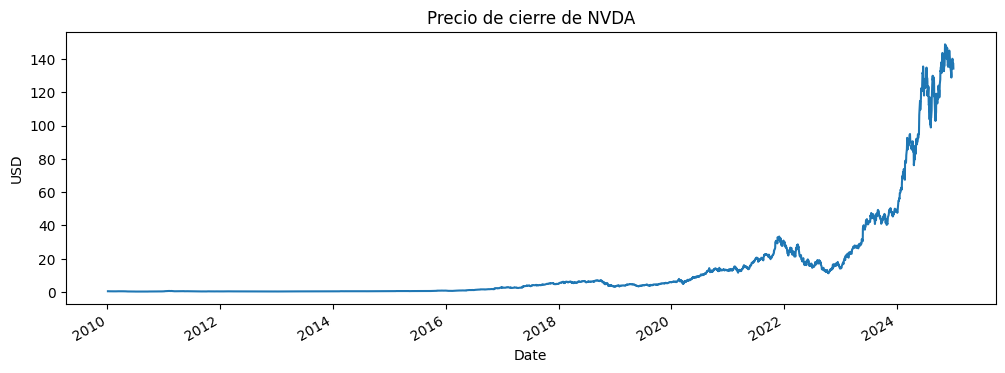

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Predicción de cierre (10 días):
3774    134.740936
3775    134.862675
3776    135.472408
3777    135.518732
3778    135.510894
3779    135.271104
3780    135.039827
3781    135.139453
3782    134.874332
3783    135.112221
Name: predicted_mean, dtype: float64

¿Sube respecto al último cierre?
Día 1: Sube (predicho: 134.74, actual: 134.28)
Día 2: Sube (predicho: 134.86, actual: 134.28)
Día 3: Sube (predicho: 135.47, actual: 134.28)
Día 4: Sube (predicho: 135.52, actual: 134.28)
Día 5: Sube (predicho: 135.51, actual: 134.28)
Día 6: Sube (predicho: 135.27, actual: 134.28)
Día 7: Sube (predicho: 135.04, actual: 134.28)
Día 8: Sube (predicho: 135.14, actual: 134.28)
Día 9: Sube (predicho: 134.87, actual: 134.28)
Día 10: Sube (predicho: 135.11, actual: 134.28)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# Asegurarse de que 'Date' sea datetime
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar por fecha y usar 'Date' como índice
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

# Lista de columnas de cierre a analizar
tickers = ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA']

# Parámetros del modelo ARIMA
order = (10, 1, 0)

# Iterar sobre cada ticker
for ticker in tickers:
    col_name = f'Close_{ticker}'

    if col_name in df.columns:
        # Extraer la serie de tiempo
        close_series = df[col_name].dropna()  # eliminar NaNs si existen

        # Graficar la serie
        close_series.plot(title=f'Precio de cierre de {ticker}', figsize=(12, 4))
        plt.ylabel("USD")
        plt.show()

        # Ajustar modelo ARIMA
        try:
            model = ARIMA(close_series, order=order)
            model_fit = model.fit()

            # Predecir los próximos 10 días
            forecast = model_fit.forecast(steps=10)

            # Mostrar predicción
            print("Predicción de cierre (10 días):")
            print(forecast)

            # Ver si sube respecto al último valor
            ultimo = close_series.iloc[-1]
            print("\n¿Sube respecto al último cierre?")
            for i, val in enumerate(forecast):
                tendencia = 'Sube' if val > ultimo else 'Baja'
                print(f"Día {i+1}: {tendencia} (predicho: {val:.2f}, actual: {ultimo:.2f})")
        except Exception as e:
          print(f"Error al ajustar ARIMA para {ticker}: {e}")
        else:
          print(f"Columna {col_name} no encontrada en el DataFrame.")